# LIBRARY

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from pyod.models.lof import LOF
from pyod.models.loda import LODA
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

In [96]:
import numpy as np
from pyod.models.lof import LOF
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

# READ DATAFRAME

In [97]:
file_path = "../1.DATASET/CMI_FINAL_SCL.csv"
df=pd.read_csv(file_path)

In [98]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])


## LOF 

In [99]:
clf = LOF(n_neighbors=200, metric= 'euclidean', contamination= 0.01)
clf.fit(X)
outliers = clf.predict(X)
np.unique(outliers, return_counts=True)

(array([0, 1]), array([8382,   78]))

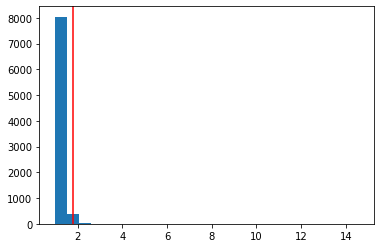

In [100]:
df['lof'] = outliers
df['lof_score']=clf.decision_scores_
plt.hist(clf.decision_function(X), bins=25)
plt.axvline(np.min(clf.decision_function(X)[np.where(outliers==1)]), c='r')
plt.show()

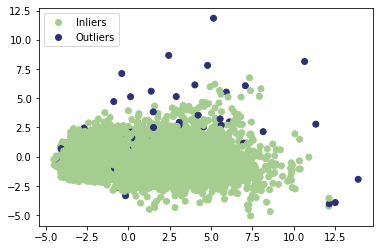

In [101]:
pca = PCA(n_components=2)
pca_data = pd.DataFrame(pca.fit_transform(X), columns=['PC1', 'PC2'])
pca_data['outlier score'] = pd.Categorical(outliers)

fig = plt.figure()
ax = fig.add_subplot()

scatter = ax.scatter(pca_data['PC1'],
                     pca_data['PC2'],
                     c=pca_data['outlier score'],
                     cmap='crest')

handles, labels = scatter.legend_elements()
plt.legend(handles, ['Inliers', 'Outliers'], loc='upper left')

plt.show()

In [102]:
df[df['lof']==1]

,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii,lof,lof_score
18,-1.186243,-0.820524,2.372831,-2.439051,-0.765276,-1.266210,-0.826682,-0.289581,-2.168466,-0.933083,-0.854355,-0.174550,-0.698228,-0.600141,-1.264876,-0.829773,-0.416645,0.0,1,1.831337
59,1.891137,-0.820524,1.119982,1.485392,1.642694,1.066269,2.717543,16.823357,1.032039,1.493563,-0.556933,0.118269,2.182005,0.020963,0.498323,-0.352442,-0.153513,2.0,1,3.196922
180,-1.186243,1.218734,-1.021966,-0.830673,-0.947190,-2.295245,-0.999571,-0.289581,1.770617,-0.933083,6.931916,-0.164988,-0.639429,-1.159717,-1.264876,0.209956,-1.205336,0.0,1,2.261852
319,-1.186243,-0.820524,-1.072481,-1.667029,-1.267934,6.074239,-0.802428,-0.289581,-1.060599,-0.933083,-1.067328,-0.213255,-1.134802,-1.035222,-1.264876,-1.397926,-1.455736,0.0,1,1.891720
431,-0.906481,-0.820524,-0.789637,-0.702002,-0.803574,3.192942,2.112432,-0.236957,4.724929,0.280240,0.783306,-0.102769,-0.710429,-0.672357,0.498323,-0.636205,-0.682354,0.0,1,1.894820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7655,-1.186243,1.218734,-0.351580,-0.725163,-0.639807,-0.477283,-0.802428,1.982753,-2.168466,-0.933083,0.156701,-0.033020,-2.093603,2.298735,0.498323,-2.227138,-0.156411,0.0,1,1.907092
7704,-0.067196,1.218734,-0.197857,-0.287684,-0.353836,-0.000778,0.080986,8.044034,0.293461,0.280240,0.569303,-0.078341,-0.342349,-0.241290,-1.264876,1.238087,0.093292,0.0,1,2.095720
7764,-0.346958,-0.820524,-0.405399,-0.811372,-0.701613,-0.048543,-0.437681,-0.358400,1.278231,0.280240,0.612389,-0.191764,-2.176126,2.298735,-1.264876,-2.332225,-0.759709,2.0,1,1.896550
7968,0.772090,-0.820524,-0.366238,0.359527,-0.084930,-0.631638,-0.091903,-0.637742,-0.198925,1.493563,-0.360841,0.271612,-1.780139,3.091484,0.498323,-1.827961,0.483991,0.0,1,1.929740


In [103]:
df_out=df[df['lof']==1].copy()
list_out_lof=df_out.index.values.tolist()
total_list=df_out.index.values.tolist()
file_path = "../1.DATASET/CMI_FINAL.csv"
df_original=pd.read_csv(file_path)
df_original[df_original['id'].isin(list_out_lof)]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
18,18,6,0,30.094649,37.50,60.200000,72.333333,6.00000,18.613018,4.00,2.0,2.750350,1504.610000,49.103400,11.096600,1.0,19.888600,38.763800,0.0
59,59,17,0,24.446886,68.00,160.800000,95.000000,47.00000,115.100000,10.50,4.0,3.502280,2298.130000,139.225600,21.574400,2.0,25.752900,42.541600,2.0
180,180,6,1,14.791120,50.00,52.600000,62.333333,4.00000,18.613018,12.00,2.0,22.435300,1530.520000,50.943230,1.656770,1.0,32.662300,27.440500,0.0
319,319,6,0,14.563403,43.50,39.200000,143.666667,6.28057,18.613018,6.25,2.0,2.211920,1399.720000,35.443050,3.756950,1.0,12.908500,23.845500,0.0
431,431,7,0,15.838447,51.00,58.600000,115.666667,40.00000,18.909726,18.00,3.0,6.890620,1699.130000,48.721650,9.878350,2.0,22.266700,34.949000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7655,7655,6,1,17.813178,50.82,65.441825,80.000000,6.28057,31.425000,4.00,2.0,5.306462,1888.146627,5.442259,59.999567,2.0,2.721129,42.500000,0.0
7704,7704,10,1,18.506154,54.22,77.389115,84.630603,16.50000,65.600000,9.00,3.0,6.349588,1765.330589,60.238836,17.150279,1.0,45.293513,46.084999,0.0
7764,7764,9,0,17.570567,50.15,62.859703,84.166427,10.50000,18.225000,11.00,3.0,6.458514,1457.960761,2.860137,59.999567,1.0,1.430068,33.838410,2.0
7968,7968,13,0,17.747100,59.25,88.623475,78.500000,14.50000,16.650000,8.00,4.0,3.998032,2713.680000,15.250529,73.372946,2.0,7.625265,51.694288,0.0


In [104]:
df.sort_values(by='lof_score', ascending=False)

,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii,lof,lof_score
3205,-0.346958,1.218734,-0.538115,-0.315992,-0.521128,1.615088,-0.913126,-0.362028,-0.322021,-0.933083,-0.815152,45.296331,-0.498768,-0.365465,0.498323,-0.196215,1.529170,0.0,1,14.670397
5448,-0.067196,-0.820524,-0.461258,0.452170,-0.085512,-0.871746,0.599653,6.332509,-2.168466,-0.933083,0.693365,45.296331,-0.038054,-0.141189,0.498323,0.777032,0.983779,0.0,1,11.361473
6273,1.611376,-0.820524,2.702671,1.719571,3.035697,3.604556,-0.091903,1.147225,0.293461,0.280240,0.719826,45.296331,1.279724,5.144318,2.261521,2.321604,2.457557,0.0,1,9.746571
5615,0.772090,1.218734,0.111018,1.193310,0.720930,-0.408681,0.340319,1.933979,1.770617,1.493563,0.462944,29.146070,0.702161,0.483023,0.498323,1.369306,1.995972,0.0,1,7.587015
6763,0.492328,1.218734,-0.194977,1.539433,0.745555,-1.077553,-0.005459,0.612647,-1.429888,-2.146406,0.279029,21.240536,0.245653,1.390742,0.498323,0.728534,-0.217937,2.0,1,7.035889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7886,-0.626720,-0.820524,-0.243508,-0.852547,-0.659054,-0.176169,-0.431777,-0.398306,0.047268,0.280240,-0.238514,-0.097927,-0.575317,-0.565058,-1.264876,-0.614083,-0.662749,0.0,0,0.959790
1849,-0.346958,-0.820524,-0.323961,-0.235444,-0.383748,-0.048543,-0.308015,-0.362028,0.043536,0.280240,-0.589611,-0.029414,-0.339509,-0.320636,0.498323,-0.489749,-0.156411,0.0,0,0.959650
3089,-0.346958,-0.820524,-0.487602,-0.187322,-0.434686,-0.048543,-0.308015,-0.362028,0.043536,0.280240,-0.589611,-0.029414,-0.379665,-0.372302,0.498323,-0.489749,-0.164769,0.0,0,0.959385
3562,-0.346958,-0.820524,-0.487602,-0.092106,-0.386695,-0.048543,-0.239970,-0.362028,0.043536,0.280240,-0.589611,-0.029414,-0.315588,-0.372302,0.498323,-0.362063,-0.164769,0.0,0,0.959363


In [105]:
df_original[df_original['id']==3205]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
3205,3205,9,1,16.972291,54.0,70.4,100.333333,5.0,18.204545,7.75,2.0,2.84946,124728.0,55.3445,15.0555,2.0,27.67225,66.7,0.0


## LODA

In [106]:
clf = LODA(contamination=0.01, n_bins='auto', n_random_cuts=100)

In [107]:
clf.fit(X)
outliers = clf.predict(X)
np.unique(outliers, return_counts=True)

(array([0, 1]), array([8375,   85]))

In [108]:
df['loda'] = outliers

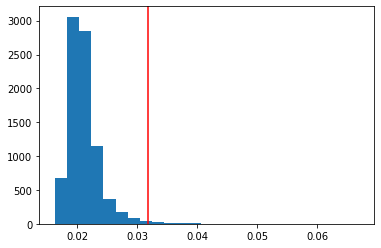

In [109]:
plt.hist(clf.decision_function(X), bins=25)
plt.axvline(np.min(clf.decision_function(X)[np.where(outliers==1)]), c='r')

plt.show()

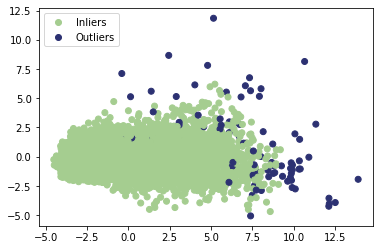

In [110]:
pca = PCA(n_components=2)
pca_data = pd.DataFrame(pca.fit_transform(X), columns=['PC1', 'PC2'])
pca_data['outlier score'] = pd.Categorical(outliers)

fig = plt.figure()
ax = fig.add_subplot()

scatter = ax.scatter(pca_data['PC1'],
                     pca_data['PC2'],
                     c=pca_data['outlier score'],
                     cmap='crest')

handles, labels = scatter.legend_elements()
plt.legend(handles, ['Inliers', 'Outliers'], loc='upper left')

plt.show()

In [111]:
df[df['loda']==1]

,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,...,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii,lof,lof_score,loda
59,1.891137,-0.820524,1.119982,1.485392,1.642694,1.066269,2.717543,16.823357,1.032039,1.493563,...,0.118269,2.182005,0.020963,0.498323,-0.352442,-0.153513,2.0,1,3.196922,1
87,1.891137,-0.820524,1.604434,2.643424,3.169816,1.169173,3.668433,4.576644,4.109447,0.280240,...,-0.029414,4.079742,0.282971,0.498323,-0.362063,-0.217937,0.0,0,1.709852,1
306,1.611376,-0.820524,5.923960,1.421056,4.945873,1.615088,-0.394459,2.545871,-2.783948,-2.146406,...,0.335613,3.447218,5.854619,2.261521,4.250539,6.081284,3.0,0,1.703390,1
489,1.891137,-0.820524,3.464803,1.678397,3.552793,3.844664,1.247987,5.827033,3.321630,2.706886,...,1.138110,3.066769,3.110291,0.498323,5.521929,5.508395,0.0,1,1.904966,1
570,1.331614,-0.820524,3.040605,1.614062,3.160241,3.535953,0.556430,3.033612,1.032039,-0.933083,...,0.509425,3.031851,2.202897,2.261521,5.279646,5.489589,1.0,0,1.442806,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7475,1.891137,-0.820524,3.795740,2.155763,4.456298,1.289227,0.945431,3.242010,-0.198925,-0.933083,...,0.390591,5.614364,0.622540,2.261521,2.867501,3.821094,1.0,0,1.324728,1
7690,1.611376,-0.820524,3.350932,1.352861,3.062747,-0.254325,1.204764,0.625949,-1.429888,-2.146406,...,-0.108675,4.403982,-0.583590,2.261521,1.580536,1.231443,0.0,0,1.283734,1
8161,1.051852,-0.820524,2.993077,1.387602,2.856983,-0.048518,0.426764,8.527340,0.047268,-0.933083,...,0.196411,2.738718,1.995575,0.498323,2.320809,1.238358,0.0,0,1.656023,1
8249,3.010185,-0.820524,3.039501,1.875262,3.479797,0.859683,2.717543,1.738883,-0.937503,1.493563,...,0.275785,2.407414,4.152492,0.498323,2.169171,2.231762,2.0,0,1.309495,1


In [112]:
df_out=df[df['loda']==1].copy()
list_out_loda=df_out.index.values.tolist()
total_list= total_list+list_out_loda
file_path = "../1.DATASET/CMI_FINAL.csv"
df_original=pd.read_csv(file_path)
df_original[df_original['id'].isin(list_out_loda)]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
59,59,17,0,24.446886,68.00,160.800000,95.000000,47.0,115.100,10.50000,4.0,3.502280,2298.130000,139.225600,21.574400,2.0,25.752900,42.541600,2.0
87,87,17,0,26.630764,77.00,224.600000,96.000000,58.0,46.050,16.75000,3.0,3.419664,1897.920000,198.605620,25.994380,2.0,25.634700,41.616667,0.0
306,306,16,0,46.102914,67.50,298.800000,100.333333,11.0,34.600,2.75000,1.0,7.434780,2887.120000,178.814000,119.986000,3.0,82.303300,132.055000,3.0
489,489,17,0,35.017194,69.50,240.600000,122.000000,30.0,53.100,15.15000,5.0,11.632400,5061.840000,166.909800,73.690200,2.0,97.923100,123.830000,0.0
570,570,15,0,33.104936,69.00,224.200000,119.000000,22.0,37.350,10.50000,2.0,7.882090,3358.140000,165.817200,58.382800,3.0,94.946500,123.560000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7475,7475,17,0,36.509036,73.21,278.346559,97.166667,26.5,38.525,8.00000,2.0,7.069773,3036.108086,246.623780,31.722779,3.0,65.311851,99.605311,1.0
7690,7690,16,0,34.503869,66.97,220.126872,82.166667,29.5,23.775,5.50000,1.0,4.159334,1683.126722,208.751067,11.375805,3.0,49.500700,62.425503,0.0
8161,8161,14,0,32.890681,67.24,211.530476,84.166667,20.5,68.325,8.50000,2.0,6.788772,2509.890000,156.645109,54.885367,2.0,58.595400,62.524793,0.0
8249,8249,21,0,33.099957,71.03,237.550382,92.992424,47.0,30.050,6.50000,4.0,12.054014,2724.990085,146.278629,91.271753,2.0,56.732441,76.787154,2.0


## Isolation Forest

In [113]:
clf = IsolationForest(random_state=42, n_estimators=100, contamination=0.01, n_jobs=-1)

In [114]:
clf.fit(X)
outliers = clf.predict(X)

In [115]:
df['iforest'] = outliers
# Mapping all outliers to 1 and all inliers to 0
df['iforest'] = df['iforest'].map({-1: 1, 1: 0})
np.unique(outliers, return_counts=True)

(array([-1,  1]), array([  85, 8375]))

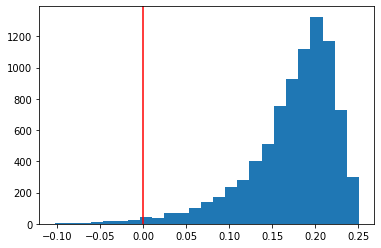

In [116]:
plt.hist(clf.decision_function(X), bins=25)
plt.axvline(np.min(clf.decision_function(X)[np.where(outliers==1)]), c='r')

plt.show()

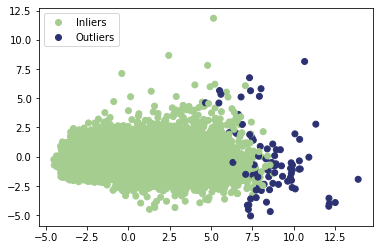

In [117]:
pca = PCA(n_components=2)
pca_data = pd.DataFrame(pca.fit_transform(X), columns=['PC1', 'PC2'])
pca_data['outlier score'] = pd.Categorical(outliers)

fig = plt.figure()
ax = fig.add_subplot()

scatter = ax.scatter(
    pca_data['PC1'],
    pca_data['PC2'],
    c=pca_data['outlier score'],
    cmap='crest_r'
)

handles, labels = scatter.legend_elements()
plt.legend(reversed(handles), ['Inliers', 'Outliers'], loc='upper left')

plt.show()

In [118]:
df[df['iforest']==1]

,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,...,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii,lof,lof_score,loda,iforest
87,1.891137,-0.820524,1.604434,2.643424,3.169816,1.169173,3.668433,4.576644,4.109447,0.280240,...,4.079742,0.282971,0.498323,-0.362063,-0.217937,0.0,0,1.709852,1,1
306,1.611376,-0.820524,5.923960,1.421056,4.945873,1.615088,-0.394459,2.545871,-2.783948,-2.146406,...,3.447218,5.854619,2.261521,4.250539,6.081284,3.0,0,1.703390,1,1
436,2.450661,-0.820524,1.743502,1.614062,2.212372,5.491120,0.062976,0.067264,0.293461,0.280240,...,2.168227,1.457338,2.261521,3.477121,4.092228,0.0,0,1.515239,0,1
459,1.331614,-0.820524,1.877108,2.482586,3.236837,0.386664,1.075098,3.015876,0.293461,0.280240,...,2.798459,2.825483,2.261521,3.906176,4.933069,2.0,0,1.214293,0,1
489,1.891137,-0.820524,3.464803,1.678397,3.552793,3.844664,1.247987,5.827033,3.321630,2.706886,...,3.066769,3.110291,0.498323,5.521929,5.508395,0.0,1,1.904966,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7734,1.891137,-0.820524,3.819542,1.753026,3.916722,0.435384,0.945431,1.424069,0.047268,2.706886,...,4.234252,1.846113,0.498323,3.345438,2.242476,0.0,0,1.250413,0,1
8155,1.331614,-0.820524,4.398420,1.583181,4.108318,-0.563036,-0.351237,1.094617,0.293461,-2.146406,...,3.145329,4.340344,2.261521,1.112424,1.256820,0.0,0,1.264705,0,1
8193,0.492328,-0.820524,3.271192,1.707991,3.446481,0.980517,2.328543,0.067458,-2.660851,-2.146406,...,4.194492,0.755298,0.498323,3.544814,3.778003,0.0,0,1.355891,0,1
8249,3.010185,-0.820524,3.039501,1.875262,3.479797,0.859683,2.717543,1.738883,-0.937503,1.493563,...,2.407414,4.152492,0.498323,2.169171,2.231762,2.0,0,1.309495,1,1


In [119]:
df_out=df[df['iforest']==1].copy()
list_out_iforest=df_out.index.values.tolist()
total_list= total_list+list_out_iforest
file_path = "../1.DATASET/CMI_FINAL.csv"
df_original=pd.read_csv(file_path)
df_original[df_original['id'].isin(list_out_iforest)]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
87,87,17,0,26.630764,77.00,224.600000,96.000000,58.000000,46.050000,16.75000,3.0,3.419664,1897.920000,198.605620,25.994380,2.0,25.634700,41.616667,0.0
306,306,16,0,46.102914,67.50,298.800000,100.333333,11.000000,34.600000,2.75000,1.0,7.434780,2887.120000,178.814000,119.986000,3.0,82.303300,132.055000,3.0
436,436,19,0,27.257677,69.00,184.600000,138.000000,16.291667,20.625000,9.00000,3.0,3.872050,3136.730000,138.794500,45.805500,3.0,72.801400,103.498000,0.0
459,459,15,0,27.859961,75.75,227.400000,88.395702,28.000000,37.250000,9.00000,3.0,8.684580,3451.470000,158.514400,68.885600,3.0,78.072600,115.570000,2.0
489,489,17,0,35.017194,69.50,240.600000,122.000000,30.000000,53.100000,15.15000,5.0,11.632400,5061.840000,166.909800,73.690200,2.0,97.923100,123.830000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7734,7734,17,0,36.616331,70.08,255.804212,88.869159,26.500000,28.275000,8.50000,5.0,8.606028,3076.260721,203.440212,52.364000,2.0,71.183587,76.940980,0.0
8155,8155,15,0,39.225876,68.76,263.808670,79.166667,11.500000,26.417470,9.00000,1.0,2.681194,2154.982326,169.367927,94.440742,3.0,43.749664,62.789843,0.0
8193,8193,12,0,34.144407,69.73,236.158501,94.166667,42.500000,20.626092,3.00000,1.0,6.688502,3353.265543,202.196141,33.962360,2.0,73.633044,98.986639,0.0
8249,8249,21,0,33.099957,71.03,237.550382,92.992424,47.000000,30.050000,6.50000,4.0,12.054014,2724.990085,146.278629,91.271753,2.0,56.732441,76.787154,2.0


# Comparing Outliers

In [120]:
len(total_list)

248

In [121]:
from collections import Counter

count = Counter(total_list)

# Items that appear EXACTLY 2 times
twice = {k: v for k, v in count.items() if v >= 2}

# Items that appear EXACTLY 3 times
triple = {k: v for k, v in count.items() if v == 3}

# Items that appear MORE THAN 2 times
once = {k: v for k, v in count.items() if v ==1}

print(f"Appear once: {len(once)} items → {once}")
print(f"Appear exactly 2 times : {len(twice)}  items → {twice}")
print(f"Appear exactly 3 times : {len(triple)}  items → {triple}")

Appear once: 94 items → {18: 1, 180: 1, 319: 1, 431: 1, 583: 1, 825: 1, 2039: 1, 2113: 1, 2443: 1, 2673: 1, 2809: 1, 2854: 1, 3471: 1, 3511: 1, 3547: 1, 3818: 1, 3922: 1, 4139: 1, 4152: 1, 4230: 1, 4264: 1, 4385: 1, 4469: 1, 4576: 1, 4588: 1, 5193: 1, 5283: 1, 5285: 1, 5797: 1, 5838: 1, 6107: 1, 6287: 1, 6406: 1, 6496: 1, 6573: 1, 6767: 1, 6878: 1, 7442: 1, 7655: 1, 7704: 1, 7764: 1, 7968: 1, 8236: 1, 720: 1, 1212: 1, 2128: 1, 2215: 1, 2245: 1, 2255: 1, 4515: 1, 6210: 1, 6495: 1, 7690: 1, 8161: 1, 436: 1, 459: 1, 577: 1, 632: 1, 650: 1, 798: 1, 1136: 1, 1317: 1, 1460: 1, 1517: 1, 1520: 1, 1607: 1, 1702: 1, 1723: 1, 1920: 1, 2203: 1, 2292: 1, 2410: 1, 2504: 1, 2688: 1, 2691: 1, 2749: 1, 2789: 1, 3051: 1, 3154: 1, 3386: 1, 3451: 1, 3538: 1, 3642: 1, 3771: 1, 4222: 1, 5414: 1, 5708: 1, 6346: 1, 6395: 1, 6657: 1, 7431: 1, 7734: 1, 8155: 1, 8193: 1}
Appear exactly 2 times : 74  items → {59: 2, 489: 3, 617: 2, 872: 3, 921: 3, 994: 2, 1762: 2, 2027: 2, 2033: 2, 2112: 3, 2350: 2, 2717: 2, 3017

In [122]:
df_original['score'] = df_original.apply(lambda x: 1 if x['id'] in twice else 0, axis=1)
df_original[df_original['score']==1]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii,score
59,59,17,0,24.446886,68.000000,160.800000,95.000000,47.000000,115.100000,10.50000,4.0,3.502280,2298.130000,139.225600,21.574400,2.0,25.752900,42.541600,2.0,1
87,87,17,0,26.630764,77.000000,224.600000,96.000000,58.000000,46.050000,16.75000,3.0,3.419664,1897.920000,198.605620,25.994380,2.0,25.634700,41.616667,0.0,1
306,306,16,0,46.102914,67.500000,298.800000,100.333333,11.000000,34.600000,2.75000,1.0,7.434780,2887.120000,178.814000,119.986000,3.0,82.303300,132.055000,3.0,1
489,489,17,0,35.017194,69.500000,240.600000,122.000000,30.000000,53.100000,15.15000,5.0,11.632400,5061.840000,166.909800,73.690200,2.0,97.923100,123.830000,0.0,1
570,570,15,0,33.104936,69.000000,224.200000,119.000000,22.000000,37.350000,10.50000,2.0,7.882090,3358.140000,165.817200,58.382800,3.0,94.946500,123.560000,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7224,7224,9,1,18.000000,67.085714,115.233108,84.166427,12.787145,18.204545,8.49242,3.0,41.515953,1711.477348,99.668648,15.564460,1.0,29.923986,29.879288,0.0,1
7304,7304,9,0,16.101998,56.800000,73.896033,80.833333,12.787145,14.775000,3.00000,1.0,33.027024,1767.697081,64.697952,9.198081,2.0,25.830364,36.283486,0.0,1
7475,7475,17,0,36.509036,73.210000,278.346559,97.166667,26.500000,38.525000,8.00000,2.0,7.069773,3036.108086,246.623780,31.722779,3.0,65.311851,99.605311,1.0,1
8249,8249,21,0,33.099957,71.030000,237.550382,92.992424,47.000000,30.050000,6.50000,4.0,12.054014,2724.990085,146.278629,91.271753,2.0,56.732441,76.787154,2.0,1


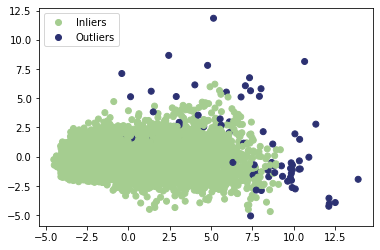

In [123]:
pca = PCA(n_components=2)
pca_data = pd.DataFrame(pca.fit_transform(X), columns=['PC1', 'PC2'])
pca_data['score']= df_original['score'].values
fig = plt.figure()
ax = fig.add_subplot()

scatter = ax.scatter(pca_data['PC1'],
                     pca_data['PC2'],
                     c=pca_data['score'],
                     cmap='crest')

handles, labels = scatter.legend_elements()
plt.legend(handles, ['Inliers', 'Outliers'], loc='upper left')

# FINAL DATASET

In [124]:
df_original.columns

Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_FFM', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'sii', 'score'],
      dtype='object')

In [125]:
df_original.drop(columns=['score'], inplace=True)

In [126]:
df_original[(df_original['id'].isin(twice))]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
59,59,17,0,24.446886,68.000000,160.800000,95.000000,47.000000,115.100000,10.50000,4.0,3.502280,2298.130000,139.225600,21.574400,2.0,25.752900,42.541600,2.0
87,87,17,0,26.630764,77.000000,224.600000,96.000000,58.000000,46.050000,16.75000,3.0,3.419664,1897.920000,198.605620,25.994380,2.0,25.634700,41.616667,0.0
306,306,16,0,46.102914,67.500000,298.800000,100.333333,11.000000,34.600000,2.75000,1.0,7.434780,2887.120000,178.814000,119.986000,3.0,82.303300,132.055000,3.0
489,489,17,0,35.017194,69.500000,240.600000,122.000000,30.000000,53.100000,15.15000,5.0,11.632400,5061.840000,166.909800,73.690200,2.0,97.923100,123.830000,0.0
570,570,15,0,33.104936,69.000000,224.200000,119.000000,22.000000,37.350000,10.50000,2.0,7.882090,3358.140000,165.817200,58.382800,3.0,94.946500,123.560000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7224,7224,9,1,18.000000,67.085714,115.233108,84.166427,12.787145,18.204545,8.49242,3.0,41.515953,1711.477348,99.668648,15.564460,1.0,29.923986,29.879288,0.0
7304,7304,9,0,16.101998,56.800000,73.896033,80.833333,12.787145,14.775000,3.00000,1.0,33.027024,1767.697081,64.697952,9.198081,2.0,25.830364,36.283486,0.0
7475,7475,17,0,36.509036,73.210000,278.346559,97.166667,26.500000,38.525000,8.00000,2.0,7.069773,3036.108086,246.623780,31.722779,3.0,65.311851,99.605311,1.0
8249,8249,21,0,33.099957,71.030000,237.550382,92.992424,47.000000,30.050000,6.50000,4.0,12.054014,2724.990085,146.278629,91.271753,2.0,56.732441,76.787154,2.0


In [127]:
df_original.drop(index=df_original[(df_original['id'].isin(twice))].index, inplace=True)


In [128]:
df_original.describe()

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
count,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000,8386.000000
mean,4233.709516,10.202361,0.404007,19.315185,56.357774,91.266701,84.594627,15.410618,20.110275,8.401362,2.769616,4.848974,1895.313115,70.350088,20.916614,1.712020,29.838779,44.449456,0.441450
std,2443.527949,3.548751,0.490728,4.352373,7.709437,40.148600,9.688885,11.142301,5.175741,2.016046,0.820932,2.229487,492.919702,30.271311,16.205135,0.563185,11.793235,13.713567,0.729296
min,0.000000,5.000000,0.000000,8.522436,33.000000,31.800000,37.666667,0.500000,0.100000,1.000000,1.000000,0.009889,1073.450000,1.181133,0.026117,1.000000,0.590566,20.589200,0.000000
25%,2117.250000,7.000000,0.000000,16.483402,50.750000,62.434053,79.666667,8.000000,18.025000,7.500000,2.000000,3.328853,1601.695000,50.349623,10.405025,1.000000,22.588512,36.406994,0.000000
50%,4236.500000,10.000000,0.000000,17.937682,55.025000,77.575018,83.333333,12.787145,18.613018,8.500000,3.000000,4.484321,1800.886263,61.837168,15.811750,2.000000,25.655500,42.380000,0.000000
75%,6350.750000,12.000000,1.000000,21.144094,62.000000,112.239592,88.166667,20.000000,20.626092,9.000000,3.000000,5.786636,2095.450000,83.420403,26.999225,2.000000,35.977868,47.142562,1.000000
max,8459.000000,22.000000,1.000000,59.132048,78.500000,291.752304,164.333333,115.000000,69.825000,21.000000,5.000000,41.422648,17311.200000,268.694823,153.820000,3.000000,94.938700,132.884000,3.000000


In [129]:
df_original.to_csv('../1.DATASET/CMI_FINAL_OD.csv', index=False)